# Predecir el precio promedio de los aguacates

**Objetivo**: Predecir el precio de los aguacates

Vamos a construir un modelo capaz de predecir el precio promedio de los aguacates. Este es un problema de regresión, porque intentamos predecir un valor numérico (un precio).

Usaremos un dataset real que contiene datos semanales de ventas de aguacates en EE. UU. 

## Paso 1: Configuración del Entorno e Importación de Librerías

Antes de empezar, necesitamos importar las herramientas que vamos a usar. Piensa en esto como si sacáramos del cajón nuestras herramientas de trabajo.

- **pandas**: La librería por excelencia para manipular y analizar datos en tablas (llamadas DataFrames).
- **matplotlib.pyplot y seaborn**: Librerías para crear gráficos y visualizaciones. seaborn es un poco más moderna y bonita que matplotlib.
- **sklearn.model_selection**: Contiene herramientas para dividir nuestros datos en conjuntos de entrenamiento y prueba.
- **sklearn.linear_model**: Aquí vive nuestro primer modelo de Machine Learning: la Regresión Lineal.
- **sklearn.metrics**: Nos da las "herramientas de medición" para evaluar qué tan bueno es nuestro modelo.

In [40]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
# Configuramos el estilo de los gráficos de seaborn para que se vean más modernos
sns.set_style("dark")

## Paso 2: Cargar y Conocer los Datos

Ahora, vamos a cargar nuestro dataset. Es un archivo CSV (valores separados por comas) que contiene toda la información sobre los aguacates.

**Importante**: Asegúrate de que el archivo avocado.csv está en la misma carpeta que este notebook.

In [10]:
# Cargamos el dataset desde el archivo CSV en un DataFrame de pandas
df = pd.read_csv('avocado.csv')

# Mostramos las primeras 5 filas para echar un vistazo a los datos
print("Primeras 5 filas del dataset:")
df.head()

Primeras 5 filas del dataset:


,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


### ¿Qué significan estas columnas?

- **Date**: La fecha de la observación.
- **AveragePrice**: El precio promedio de un solo aguacate. ¡Esta es la columna que queremos predecir!
- **Total Volume**: El número total de aguacates vendidos.
- **4046, 4225, 4770**: Códigos que identifican el volumen de ventas de aguacates de diferente tamaño (pequeño, grande, extra grande).
- **type**: Si es 'conventional' o 'organic'.
- **year**: El año.
- **region**: La ciudad o región de la observación.


### Paso 3: Exploración y Visualización de Datos (EDA)

Antes de construir un modelo, necesitamos entender nuestros datos. Esto se llama Análisis Exploratorio de Datos (EDA). Vamos a hacer algunas preguntas y a responderlas con gráficos.

**Información General del Dataset**

In [11]:
# El método .info() nos da un resumen de las columnas, el tipo de dato y si hay valores nulos
print("Información general del dataset:")
df.info()

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          18249 non-null  object 
 1   AveragePrice  18249 non-null  float64
 2   Total Volume  18249 non-null  float64
 3   4046          18249 non-null  float64
 4   4225          18249 non-null  float64
 5   4770          18249 non-null  float64
 6   Total Bags    18249 non-null  float64
 7   Small Bags    18249 non-null  float64
 8   Large Bags    18249 non-null  float64
 9   XLarge Bags   18249 non-null  float64
 10  type          18249 non-null  object 
 11  year          18249 non-null  int64  
 12  region        18249 non-null  object 
dtypes: float64(9), int64(1), object(3)
memory usage: 1.8+ MB


*Observación: Vemos que no hay valores nulos (todas las columnas tienen 18249 entradas), ¡lo cual es genial! La columna Date es un objeto (texto), así que probablemente no la usaremos en nuestro primer modelo simple.*

**¿Cómo ha evolucionado el precio con el tiempo?**

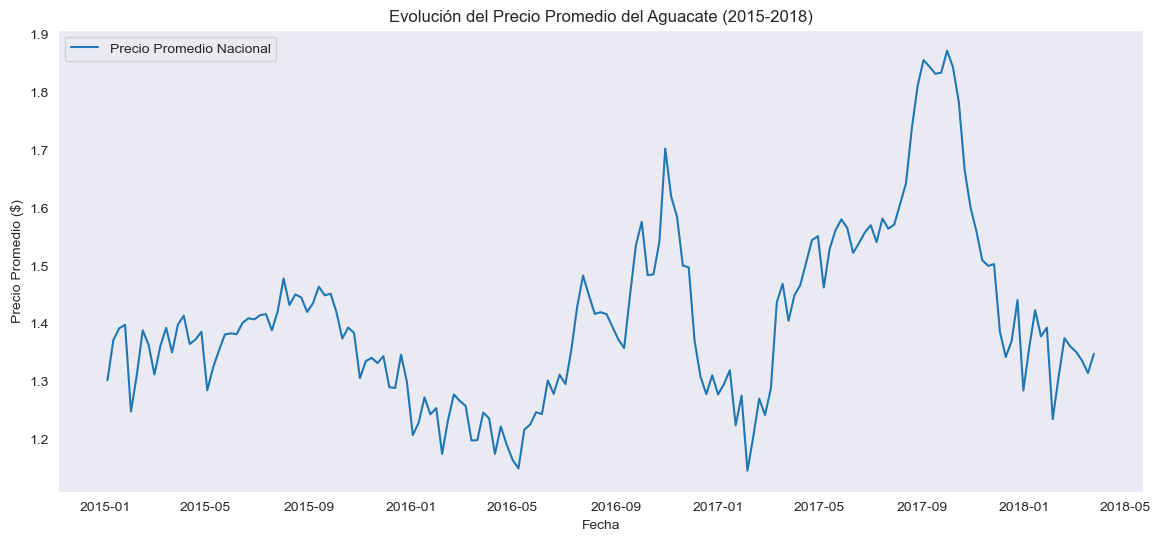

In [12]:
# Para que el gráfico sea más rápido, vamos a agrupar los datos por fecha y calcular el precio promedio nacional.
# Esto es opcional, pero ayuda a ver la tendencia general más claramente.
df_date = df.groupby('Date')['AveragePrice'].mean().reset_index()

# Convertimos la columna de fecha a un formato de fecha real para que matplotlib lo entienda
df_date['Date'] = pd.to_datetime(df_date['Date'])

# Creamos el gráfico de líneas
plt.figure(figsize=(14, 6))
plt.plot(df_date['Date'], df_date['AveragePrice'], label='Precio Promedio Nacional')
plt.title('Evolución del Precio Promedio del Aguacate (2015-2018)')
plt.xlabel('Fecha')
plt.ylabel('Precio Promedio ($)')
plt.legend()
plt.show()

*Conclusión: ¡El precio no es estable! Parece haber picos hacia principios de cada año. Esto se llama estacionalidad.*

**¿Los aguacates orgánicos son más caros?**

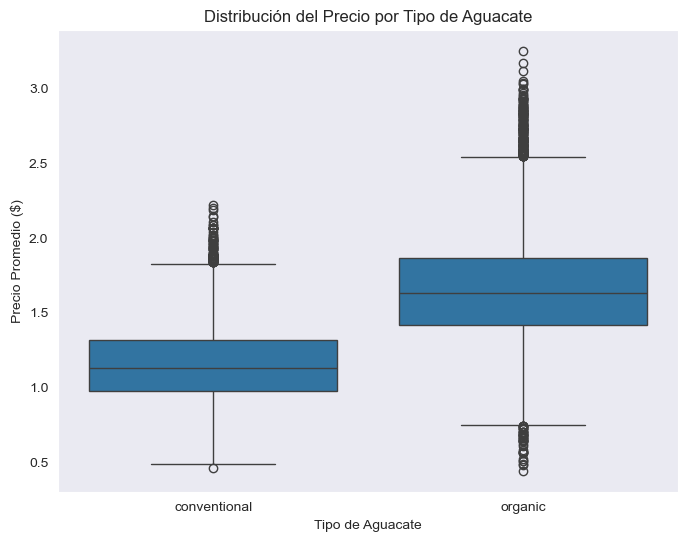

In [13]:
# Un gráfico de caja (boxplot) es perfecto para comparar distribuciones.
plt.figure(figsize=(8, 6))
sns.boxplot(x='type', y='AveragePrice', data=df)
plt.title('Distribución del Precio por Tipo de Aguacate')
plt.xlabel('Tipo de Aguacate')
plt.ylabel('Precio Promedio ($)')
plt.show()

*Conclusión: ¡Claro que sí! La caja de los aguacates "organic" está mucho más alta que la de los "conventional". Esto significa que, en general, son más caros. Esta variable (type) será muy importante para nuestro modelo.*

## Paso 4: Preparación de los Datos para el Modelo

Los modelos de Machine Learning no entienden de texto ("conventional", "organic") ni de fechas. Solo entienden números. Así que convertir nuestros datos a un formato numérico.

**a. Selección de Variables (Features)**

Vamos a elegir qué columnas usaremos para predecir el precio (AveragePrice). A estas columnas las llamamos características o features. A la columna que queremos predecir la llamamos variable objetivo o target.

Para nuestro éste modelo, usaremos las características más numéricas y directas.

In [14]:
# Definimos nuestras características (X) y nuestro objetivo (y)
# Características: volumen total y ventas por tamaño
features = ['Total Volume', '4046', '4225', '4770']
X = df[features]

# Objetivo: el precio promedio
y = df['AveragePrice']

print("Características (X):")
print(X.head())
print("\nVariable Objetivo (y):")
print(y.head())

Características (X):
   Total Volume     4046       4225    4770
0      64236.62  1036.74   54454.85   48.16
1      54876.98   674.28   44638.81   58.33
2     118220.22   794.70  109149.67  130.50
3      78992.15  1132.00   71976.41   72.58
4      51039.60   941.48   43838.39   75.78

Variable Objetivo (y):
0    1.33
1    1.35
2    0.93
3    1.08
4    1.28
Name: AveragePrice, dtype: float64


**b. Manejo de Variables Categóricas**

La columna type es muy importante, como vimos en el gráfico. Pero es texto. ¿Cómo la incluimos? Usamos una técnica llamada One-Hot Encoding, que crea nuevas columnas numéricas (0 o 1) para cada categoría.

In [15]:
# Usamos pandas para crear las nuevas columnas (dummies)
# drop_first=True evita multicolinealidad y es una buena práctica.
type_dummies = pd.get_dummies(df['type'], drop_first=True)
display(type_dummies.head())
# Unimos estas nuevas columnas a nuestras características X
X = pd.concat([X, type_dummies], axis=1)

print("Nuestras características (X) después del One-Hot Encoding:")
X.head()

,organic
0,False
1,False
2,False
3,False
4,False


Nuestras características (X) después del One-Hot Encoding:


,Total Volume,4046,4225,4770,organic
0,64236.62,1036.74,54454.85,48.16,False
1,54876.98,674.28,44638.81,58.33,False
2,118220.22,794.70,109149.67,130.50,False
3,78992.15,1132.00,71976.41,72.58,False
4,51039.60,941.48,43838.39,75.78,False


*Explicación: Ahora tenemos una nueva columna organic. Si el valor es 1, significa que el aguacate es orgánico. Si es 0, es convencional. ¡Listo para el modelo!*

In [ ]:
# Vamos a ver cuantas regiones únicas tenemos
unique_regions = df['region'].nunique()
print(f"Número de regiones únicas: {unique_regions}")
# Vamos a convertir la columna region en label-encoded
from sklearn.preprocessing import LabelEncoder  
le = LabelEncoder()
X['region'] = le.fit_transform(df['region'])
print("Nuestras características (X) después del Label Encoding de 'region':")
X.head()


Número de regiones únicas: 54
Nuestras características (X) después del Label Encoding de 'region':


,Total Volume,4046,4225,4770,organic,region
18244,17074.83,2046.96,1529.20,0.00,True,53
18245,13888.04,1191.70,3431.50,0.00,True,53
18246,13766.76,1191.92,2452.79,727.94,True,53
18247,16205.22,1527.63,2981.04,727.01,True,53
18248,17489.58,2894.77,2356.13,224.53,True,53


In [ ]:
# Vamos a estandarizar las características para que todas tengan media 0 y desviación estándar 1
# Esto es importante para muchos modelos de machine learning.
# Como por ejemplo, los modelos lineales con regularización.
# Para Linear Regression no es estrictamente necesario, pero es una buena práctica.
scaler = StandardScaler()
X_scaled_r = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_r, columns=X.columns)
print("Características estandarizadas (primeras 5 filas):")
X_scaled.head()


Características estandarizadas (primeras 5 filas):


,Total Volume,4046,4225,4770,organic,region
0,-0.227716,-0.230816,-0.199902,-0.212091,-0.999836,-1.700252
1,-0.230427,-0.231103,-0.208054,-0.211997,-0.999836,-1.700252
2,-0.212085,-0.231007,-0.154478,-0.211325,-0.999836,-1.700252
3,-0.223444,-0.230741,-0.185350,-0.211864,-0.999836,-1.700252
4,-0.231538,-0.230891,-0.208719,-0.211834,-0.999836,-1.700252


## Paso 5: Dividir los Datos en Entrenamiento y Prueba

Esta es una de las ideas más importantes en Machine Learning. No podemos usar todos nuestros datos para entrenar el modelo, porque entonces no tendríamos forma de saber si es bueno con datos que nunca ha visto.

Dividimos nuestros datos en dos partes:

- **Conjunto de Entrenamiento (Training set)**: ~80% de los datos. El modelo aprenderá de estos.
- **Conjunto de Prueba (Test set)**: ~20% de los datos. Los usaremos al final para evaluar el rendimiento del modelo de forma justa.

In [30]:
# Usamos la función train_test_split de scikit-learn
# test_size=0.2 significa que el 20% de los datos será para prueba.
# random_state=42 asegura que la división sea siempre la misma cada vez que ejecutemos el código.
# Esto es importante para que los resultados sean reproducibles.
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")

Tamaño del conjunto de entrenamiento: 14599 muestras
Tamaño del conjunto de prueba: 3650 muestras


## Paso 6: Entrenar el Modelo de Regresión Lineal

Vamos a crear nuestro modelo y a entrenarlo con nuestros datos de entrenamiento.

El proceso es muy simple en scikit-learn:

1. Crear una instancia del modelo.
2. Llamar al método .fit() con los datos de entrenamiento.

Entrenando el modelo...
¡Modelo entrenado con éxito!


array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

Mejor l1_ratio: 0.0 con R² de prueba: 0.2862109681032431
Número de características usadas en el mejor modelo: 6


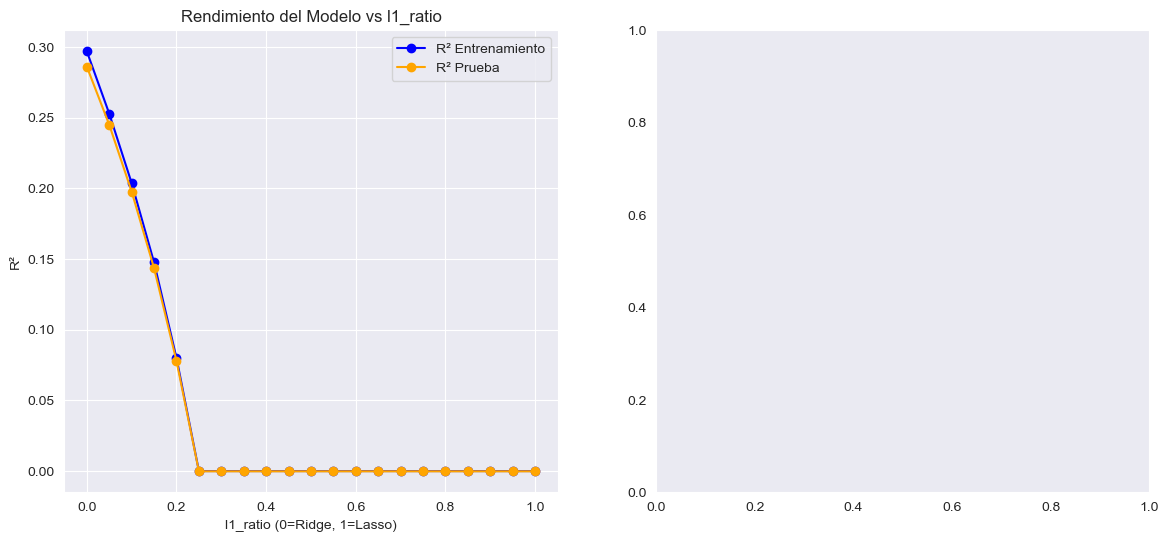

In [ ]:
# 1. Creamos una instancia del modelo de Regresión Lineal
model = LinearRegression()

# 2. Entrenamos el modelo usando los datos de entrenamiento (X_train, y_train)
# El modelo aprenderá la relación entre las características y el precio.
print("Entrenando el modelo...")
model.fit(X_train, y_train)
print("¡Modelo entrenado con éxito!")

# Ahora vamos a entrenar varios modelos con diferentes regularizaciones y comparar sus resultados
# Probemos diferentes valores de l1_ratio
l1_ratios = np.linspace(0, 1, 21)  # De 0 (Ridge) a 1 (Lasso)
display(l1_ratios)
# array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
#        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])
scores_train = []
scores_test = []
n_features_used = []
for l1_ratio in l1_ratios:  
    modelo = ElasticNet(alpha=1.0, l1_ratio=l1_ratio)
    modelo.fit(X_train, y_train)
    scores_train.append(modelo.score(X_train, y_train))
    scores_test.append(modelo.score(X_test, y_test))
    n_features_used.append(np.sum(modelo.coef_ != 0))
# Ahora vamos a visualizar los resultados en un gráfico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
# Gráfico 1: R² en entrenamiento y prueba
ax1.plot(l1_ratios, scores_train, 'o-', label='R² Entrenamiento', color='blue')
ax1.plot(l1_ratios, scores_test, 'o-', label='R² Prueba', color='orange')
ax1.set_xlabel('l1_ratio (0=Ridge, 1=Lasso)')
ax1.set_ylabel('R²')
ax1.set_title('Rendimiento del Modelo vs l1_ratio')
ax1.legend()  
ax1.grid()

# Decidimos cual es el mejor l1_ratio basado en el R² de prueba
best_index = np.argmax(scores_test)
best_l1_ratio = l1_ratios[best_index]
best_score = scores_test[best_index]
print(f"Mejor l1_ratio: {best_l1_ratio} con R² de prueba: {best_score}")
# Imprimimos las características usadas en el mejor modelo
best_model = ElasticNet(alpha=1.0, l1_ratio=best_l1_ratio)
best_model.fit(X_train, y_train)
n_features_best = np.sum(best_model.coef_ != 0)
print(f"Número de características usadas en el mejor modelo: {n_features_best}")


## Paso 7: Evaluar el Modelo

Ahora que nuestro modelo está entrenado, vamos a usar el conjunto de prueba (que nunca ha visto) para ver qué tan bueno es.

**a. Hacer Predicciones**

In [32]:
# Usamos el modelo entrenado para hacer predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test)

# Mostramos las primeras 5 predicciones junto a los valores reales
comparison_df = pd.DataFrame({'Real': y_test, 'Predicho': y_pred})
print("Comparación de precios reales vs. predichos (primeras 5 muestras):")
print(comparison_df.head())

Comparación de precios reales vs. predichos (primeras 5 muestras):
       Real  Predicho
8604   0.82  1.159417
2608   0.97  1.150430
14581  1.44  1.653906
4254   0.97  1.153092
16588  1.45  1.653747


**b. Calcular Métricas de Rendimiento**

¿Cómo medimos el error? Usaremos dos métricas comunes para regresión:

1. **Error Absoluto Medio (MAE)**: Es el promedio de los errores absolutos. En palabras simples: "En promedio, nuestro modelo se equivoca por esta cantidad de dólares". Es muy fácil de interpretar.
2. **Coeficiente de Determinación (R² o R-squared)**: Nos dice qué proporción de la variación en el precio es explicada por nuestro modelo. Un valor de 1.0 es una predicción perfecta. Un valor de 0.4 significa que nuestro modelo explica el 40% de la variabilidad del precio.

In [34]:
# Calculamos las métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error Absoluto Medio (MAE): ${mae:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): ${rmse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")

Error Absoluto Medio (MAE): $0.24
Raíz del Error Cuadrático Medio (RMSE): $0.32
Coeficiente de Determinación (R²): 0.38


*Interpretación:*

- **MAE**: Nuestro modelo, en promedio, se equivoca por unos $0.23 al predecir el precio de un aguacate. ¡No está nada mal para un primer modelo!
- **RMSE**: La raíz del error cuadrático medio es 0.32, lo que indica que la desviación típica o "error estándar" de las predicciones respecto al precio real es un poco mayor que el MAE. Como el RMSE penaliza más los errores grandes, esto sugiere que algunas predicciones tienen errores mayores que la media. En otras palabras, aunque el error promedio es 0.24, hay ciertos casos donde el error fue más alto, elevando el valor de RMSE.
- **R²**: Nuestro modelo explica alrededor del 43% de la variabilidad en el precio. Hay un 57% de la variabilidad que nuestro modelo simple no captura (quizás por la región, la estacionalidad, etc.). Esto nos da un margen de mejora.

## Paso 8: Visualizar los Resultados

Un gráfico de dispersión comparando los precios reales con los predichos es una excelente manera de visualizar el rendimiento.

Si el modelo fuera perfecto, todos los puntos estarían sobre una línea diagonal recta.

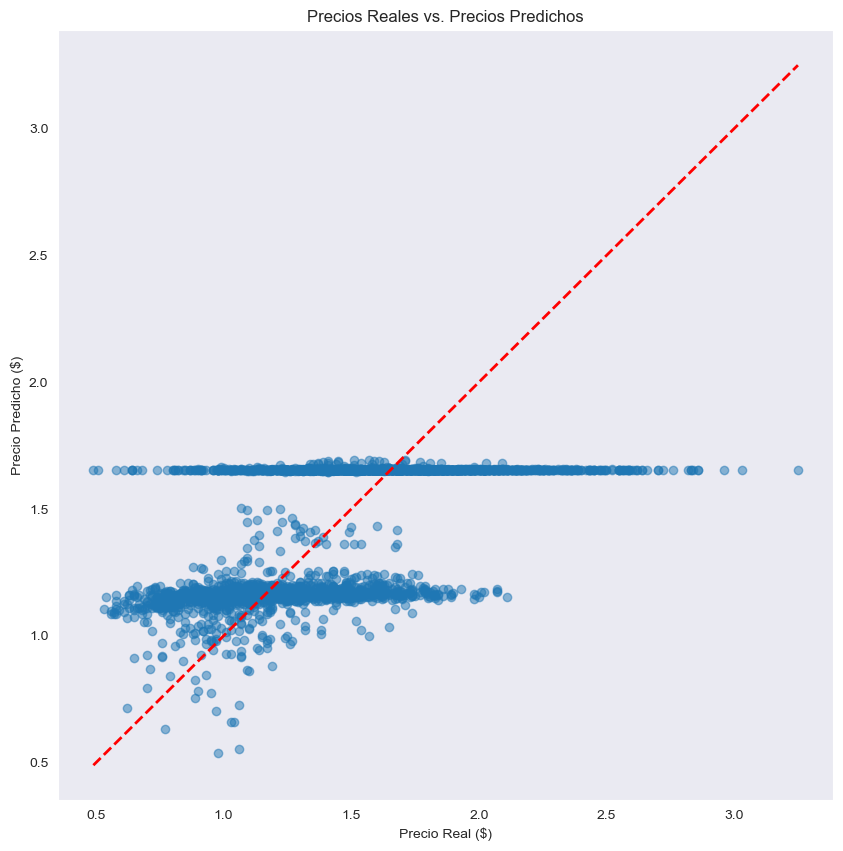

In [20]:
plt.figure(figsize=(10, 10))
plt.scatter(y_test, y_pred, alpha=0.5) # alpha hace los puntos más transparentes para ver la densidad
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', linewidth=2) # Línea de predicción perfecta
plt.title('Precios Reales vs. Precios Predichos')
plt.xlabel('Precio Real ($)')
plt.ylabel('Precio Predicho ($)')
plt.show()

*Conclusión del Gráfico*: Vemos que los puntos siguen una tendencia diagonal, lo cual es bueno. Sin embargo, hay bastante dispersión alrededor de la línea, lo que confirma que el modelo tiene un error considerable (como vimos con el MAE y el R²).

## Conclusión y Próximos Pasos

**¿Qué hemos logrado?**

- Cargamos y exploramos un dataset real.
- Preparamos los datos para un modelo (manejo de variables categóricas).
- Dividimos los datos correctamente en entrenamiento y prueba.
- Entrenamos un modelo de Regresión Lineal.
- Evaluamos su rendimiento con métricas claras y una visualización.

**¿Cómo podríamos mejorarlo?**

- **Incluir más características**: ¿Y si usáramos la region o el año? (Esto requeriría más preprocesamiento).
- **Probar otros modelos**: La Regresión Lineal es el punto de partida. Modelos más complejos como RandomForestRegressor o GradientBoostingRegressor podrían capturar mejor las relaciones no lineales y mejorar el R².
- **Ingeniería de característica**s: Podríamos crear nuevas características, como el mes a partir de la fecha, para capturar mejor la estacionalidad (primavera, verano, otoño, invierno).